# Task 4 - Loan Approval Prediction

Predicting whether a loan application will be approved or rejected using classification models.
Dataset: Loan-Approval-Prediction-Dataset from Kaggle (4,269 applications).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Loading the data
The column names and text values in the file have a space at the start, so I removed them first.

In [2]:
df = pd.read_csv("loan_approval_dataset.csv")
print(df.columns.tolist())

['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [3]:
df.columns = df.columns.str.strip()

for col in ["education", "self_employed", "loan_status"]:
    df[col] = df[col].str.strip()

print(df.columns.tolist())
print(df["loan_status"].unique())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']
['Approved' 'Rejected']


In [4]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## 2. Understanding the data
No missing values or duplicates, but residential_assets_value has negative values, which is not possible. The classes are imbalanced: 62% approved and 38% rejected.

In [5]:
df.shape

(4269, 13)

In [6]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


In [7]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [8]:
df["loan_status"].value_counts()

,count
loan_status,
Approved,2656
Rejected,1613


## 3. Data cleaning
I removed loan_id because it is just an ID. The 28 negative residential asset values were treated as missing and filled with the median.

In [9]:
df = df.drop(columns="loan_id")

print("Negative residential values:", (df["residential_assets_value"] < 0).sum())

df.loc[df["residential_assets_value"] < 0, "residential_assets_value"] = np.nan
print("Missing after marking them:", df["residential_assets_value"].isnull().sum())

median_value = df["residential_assets_value"].median()
df["residential_assets_value"] = df["residential_assets_value"].fillna(median_value)
print("Filled with median:", median_value)
print("Missing now:", df.isnull().sum().sum())

Negative residential values: 28
Missing after marking them: 28
Filled with median: 5700000.0
Missing now: 0


## 4. Visualisation

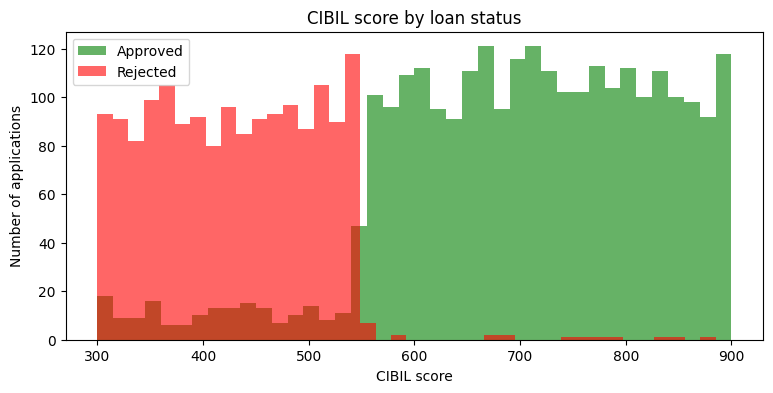

In [10]:
approved = df[df["loan_status"] == "Approved"]
rejected = df[df["loan_status"] == "Rejected"]

plt.figure(figsize=(9, 4))
plt.hist(approved["cibil_score"], bins=40, alpha=0.6, label="Approved", color="green")
plt.hist(rejected["cibil_score"], bins=40, alpha=0.6, label="Rejected", color="red")
plt.title("CIBIL score by loan status")
plt.xlabel("CIBIL score")
plt.ylabel("Number of applications")
plt.legend()
plt.show()

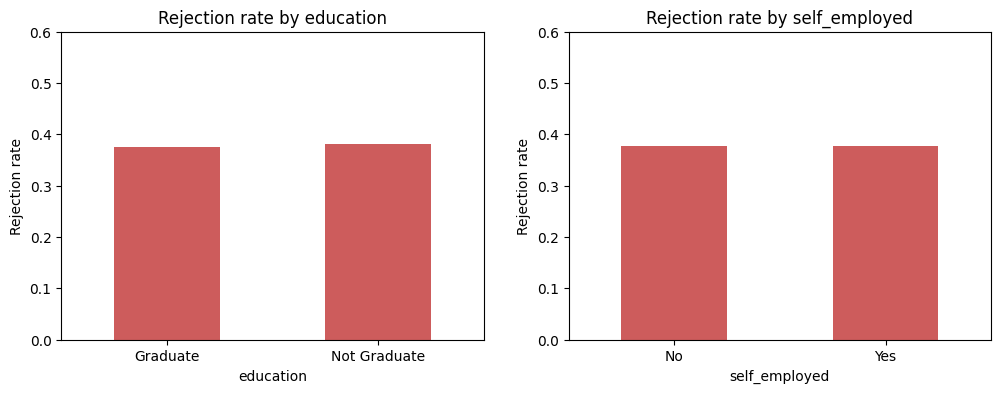

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ["education", "self_employed"]):
    rate = pd.crosstab(df[col], df["loan_status"], normalize="index")["Rejected"]
    rate.plot(kind="bar", ax=ax, color="indianred", rot=0)
    ax.set_title(f"Rejection rate by {col}")
    ax.set_ylabel("Rejection rate")
    ax.set_ylim(0, 0.6)

plt.show()

## 5. Encoding
The three text columns only have two values each, so I changed them to 0 and 1. Rejected is 1 because it is the smaller class and the one the bank most needs to catch.

In [12]:
df["education"] = df["education"].map({"Graduate": 1, "Not Graduate": 0})
df["self_employed"] = df["self_employed"].map({"Yes": 1, "No": 0})
df["loan_status"] = df["loan_status"].map({"Rejected": 1, "Approved": 0})

print(df[["education", "self_employed", "loan_status"]].head())

   education  self_employed  loan_status
0          1              0            0
1          0              1            1
2          1              0            1
3          1              0            1
4          0              1            1


## 6. Train/test split
80% training and 20% testing, with stratify so both sets have the same share of rejected loans.

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="loan_status")
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Rejected share in train:", round(y_train.mean(), 3))
print("Rejected share in test:", round(y_test.mean(), 3))

Training rows: 3415
Test rows: 854
Rejected share in train: 0.378
Rejected share in test: 0.378


## 7. Logistic Regression vs Decision Tree
Logistic Regression needs scaled data, so I put StandardScaler in a pipeline with it. The Decision Tree does not need scaling.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report

log_reg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
log_reg.fit(X_train, y_train)
lr_pred = log_reg.predict(X_test)

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred, target_names=["Approved", "Rejected"], digits=3))
print("=== Decision Tree ===")
print(classification_report(y_test, tree_pred, target_names=["Approved", "Rejected"], digits=3))

=== Logistic Regression ===
              precision    recall  f1-score   support

    Approved      0.927     0.953     0.940       531
    Rejected      0.919     0.876     0.897       323

    accuracy                          0.924       854
   macro avg      0.923     0.915     0.918       854
weighted avg      0.924     0.924     0.924       854

=== Decision Tree ===
              precision    recall  f1-score   support

    Approved      0.970     0.983     0.977       531
    Rejected      0.972     0.950     0.961       323

    accuracy                          0.971       854
   macro avg      0.971     0.967     0.969       854
weighted avg      0.971     0.971     0.971       854



## 8. Confusion matrices

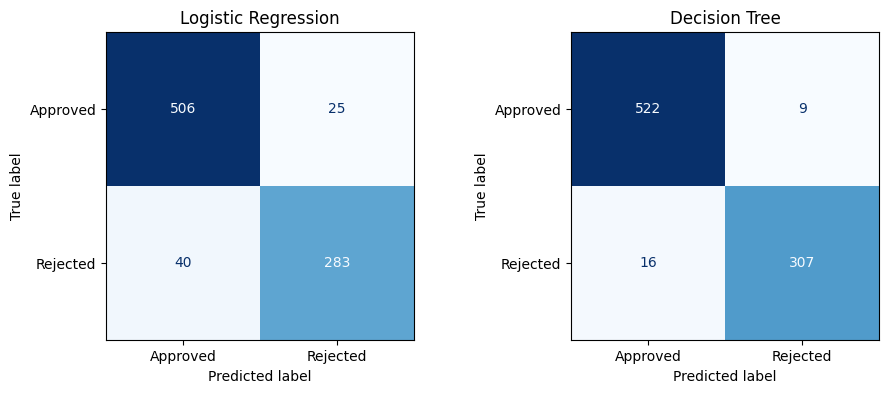

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, display_labels=["Approved", "Rejected"],
                                        cmap="Blues", colorbar=False, ax=axes[0])
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, tree_pred, display_labels=["Approved", "Rejected"],
                                        cmap="Blues", colorbar=False, ax=axes[1])
axes[1].set_title("Decision Tree")

plt.show()

## Conclusion

The dataset had 4,269 loan applications. The column names and text values had extra spaces,
so I removed them first. There were no missing values, but 28 applicants had a negative
residential asset value, so I treated them as missing and filled them with the median.
I removed loan_id and changed education, self_employed and loan_status to 0 and 1.

The data is imbalanced (62% approved, 38% rejected), so I focused on precision, recall and F1
for the Rejected class instead of only accuracy.

The CIBIL score was the most important factor. Almost all applications with a score below
about 550 were rejected and almost all above it were approved. Education and self-employment
made almost no difference (about 38% rejected in every group).

Results for the Rejected class:
- Logistic Regression: precision 0.919, recall 0.876, F1 0.897 (accuracy 92.4%)
- Decision Tree: precision 0.972, recall 0.950, F1 0.961 (accuracy 97.1%)

The Decision Tree was better. It wrongly approved only 16 loans that should have been rejected,
compared to 40 for Logistic Regression. I think this is because the decision depends on a sharp
CIBIL score cut-off, which a tree can learn directly while Logistic Regression can only draw
a smooth boundary.